In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as Gamma, zeta
from pathlib import Path

import sys
sys.path.insert(0, str(Path('../../src').resolve()))
sys.path.insert(0, str(Path('..').resolve()))
from landscape import Landscape
from cgf import psi_1, psi_2
import style_config as sc

OUT_DIR = Path(".")
L = 200
SEED = 42


def dirichlet_eta(s):
    """Dirichlet eta function: eta(s) = (1 - 2^{1-s}) zeta(s)."""
    return (1 - 2**(1 - s)) * float(zeta(s, 1))


def log_rho_peak_theory(eps, L_val, c_gamma, gamma, offset=0.0):
    """
    Near-peak log rho for power-law gap density p_gap ~ c_gamma * Delta^gamma.

    Parameters
    ----------
    eps : array, per-site fitness deficit (F_max - F) / L
    L_val : int, sequence length
    c_gamma : float, coefficient in p_gap ~ c_gamma * Delta^gamma
    gamma : float, power-law exponent (gamma > -1)
    offset : float, additive constant (e.g. lambda*L*log2 for mixture)
    """
    eps = np.asarray(eps, dtype=float)
    alpha = (1 + gamma) / (2 + gamma)
    q = 1.0 / (2 + gamma)
    A = Gamma(1 + gamma) * dirichlet_eta(2 + gamma) * c_gamma

    # Saddle-point exponent
    S = L_val * A**q * eps**alpha * ((1 + gamma)**q + (1 + gamma)**(-alpha))

    # Prefactor: -0.5 * log(2 pi Phi'')
    log_pf = (0.5 * q * np.log((1 + gamma) * A)
              - 0.5 * (1 + q) * np.log(eps)
              - 0.5 * np.log(2 * np.pi * (2 + gamma) * L_val))

    return offset + S + log_pf


print(f"Setup complete. L = {L}, C = 2, seed = {SEED}")

In [2]:
rng = np.random.default_rng(SEED)

# --- Panel (a): Gaussian theta ~ N(0,1), gamma = 0 ---
# Gap = |theta_1 - theta_2| is half-normal with sigma=sqrt(2).
# p_gap(0) = 1/sqrt(pi) for C=2.
theta_a = rng.standard_normal((L, 2))
p0_a = 1.0 / np.sqrt(np.pi)

# --- Panel (b): Power-law gaps, gamma = -1/2 (stubbier peak) ---
# p_gap(Delta) = c * Delta^{-1/2} on [0, s], generated via inverse CDF.
s_b = 4.0
gamma_b = -0.5
gaps_b = s_b * rng.uniform(size=L) ** (1.0 / (1 + gamma_b))
c_gamma_b = (1 + gamma_b) / s_b**(1 + gamma_b)
theta_b = np.column_stack([gaps_b, np.zeros(L)])

# --- Panel (c): Power-law gaps, gamma = 2 (sharper peak) ---
# p_gap(Delta) = c * Delta on [0, s].
s_c = 4.0
gamma_c = 1.0
gaps_c = s_c * rng.uniform(size=L) ** (1.0 / (1 + gamma_c))
c_gamma_c = (1 + gamma_c) / s_c**(1 + gamma_c)
theta_c = np.column_stack([gaps_c, np.zeros(L)])

# --- Panel (d): Berg-von Hippel — uniform gap Delta at all positions ---
Delta_d = 1.0
theta_d = np.column_stack([np.full(L, Delta_d), np.zeros(L)])

# --- Compute saddle-point, bulk, and peak curves ---
# Panels (a)-(c): power-law peak theory
configs_abc = [
    ("(a)", theta_a, 0.0,     p0_a),
    ("(b)", theta_b, gamma_b, c_gamma_b),
    ("(c)", theta_c, gamma_c, c_gamma_c),
]

panels = []
for label, theta, gam, c_g in configs_abc:
    land = Landscape(theta)
    f_max = land.F_max
    mu = psi_1(theta, 0.0)
    sigma = np.sqrt(psi_2(theta, 0.0))
    alpha = (1 + gam) / (2 + gam)

    margin = 0.08 * (f_max - mu)
    F_vals = np.linspace(mu - margin, f_max - 1e-3, 500)

    rho_sp = land.density(F_vals, method="saddlepoint")
    log_sp = np.full_like(F_vals, np.nan)
    ok = rho_sp > 0
    log_sp[ok] = np.log(rho_sp[ok])

    log_bulk = (L * np.log(2) - 0.5 * np.log(2 * np.pi * sigma**2)
                - (F_vals - mu)**2 / (2 * sigma**2))

    eps = np.clip((f_max - F_vals) / L, 1e-10, None)
    log_peak = log_rho_peak_theory(eps, L, c_g, gam)

    panels.append(dict(
        label=label, F=F_vals, f_max=f_max, mu=mu,
        log_sp=log_sp, log_bulk=log_bulk, log_peak=log_peak,
        gamma=gam, alpha=alpha, ok=ok, is_bvh=False,
    ))
    print(f"  {label}: gamma={gam:+.1f}, alpha={alpha:.3f}, "
          f"F_max={f_max:.1f}, F_mean={mu:.1f}")

# Panel (d): BvH — separate peak formula
land_d = Landscape(theta_d)
f_max_d = land_d.F_max
mu_d = psi_1(theta_d, 0.0)
sigma_d = np.sqrt(psi_2(theta_d, 0.0))

margin_d = 0.08 * (f_max_d - mu_d)
F_d = np.linspace(mu_d - margin_d, f_max_d - 1e-3, 500)

rho_sp_d = land_d.density(F_d, method="saddlepoint")
log_sp_d = np.full_like(F_d, np.nan)
ok_d = rho_sp_d > 0
log_sp_d[ok_d] = np.log(rho_sp_d[ok_d])

log_bulk_d = (L * np.log(2) - 0.5 * np.log(2 * np.pi * sigma_d**2)
              - (F_d - mu_d)**2 / (2 * sigma_d**2))

# BvH near-peak: log rho ~ L * (eps/Delta) * log(e*Delta/eps)
eps_d = np.clip((f_max_d - F_d) / L, 1e-10, None)
p_d = eps_d / Delta_d
log_peak_d = L * (-p_d * np.log(p_d) - (1 - p_d) * np.log(1 - p_d))

panels.append(dict(
    label="(d)", F=F_d, f_max=f_max_d, mu=mu_d,
    log_sp=log_sp_d, log_bulk=log_bulk_d, log_peak=log_peak_d,
    gamma=np.inf, alpha=1.0, ok=ok_d, is_bvh=True,
))
print(f"  (d): BvH, Delta={Delta_d}, F_max={f_max_d:.1f}, F_mean={mu_d:.1f}")

print("Done.")

  (a): gamma=+0.0, alpha=0.500, F_max=101.2, F_mean=-1.0


  (b): gamma=-0.5, alpha=0.333, F_max=270.3, F_mean=135.1
  (c): gamma=+1.0, alpha=0.667, F_max=510.5, F_mean=255.2


  (d): BvH, Delta=1.0, F_max=200.0, F_mean=100.0


Done.


Saved fig3.pdf and fig3.png


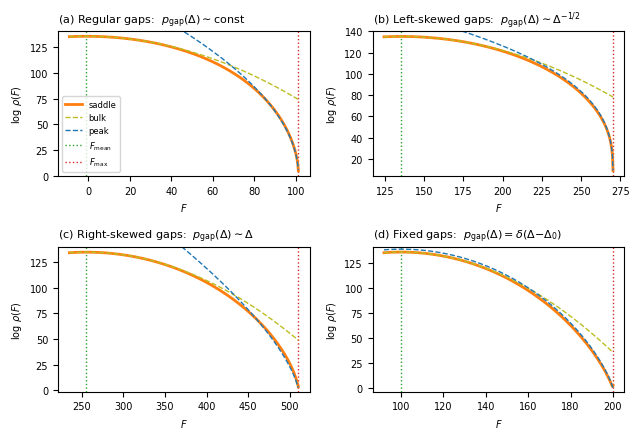

In [3]:
fig, axes = plt.subplots(2, 2, figsize=sc.FIGSIZE_2x2)

spacer = ":  "
subtitles = [
    "Regular gaps" + spacer + r"$p_\mathrm{gap}(\Delta) \sim \mathrm{const}$",
    "Left-skewed gaps" + spacer + r"$p_\mathrm{gap}(\Delta) \sim \Delta^{-1/2}$",
    "Right-skewed gaps" + spacer + r"$p_\mathrm{gap}(\Delta) \sim \Delta$",
    "Fixed gaps" + spacer + r"$p_\mathrm{gap}(\Delta) = \delta(\Delta{-}\Delta_0)$",
]

for idx, (ax, pan, sub) in enumerate(zip(axes.flat, panels, subtitles)):
    m = pan["ok"]

    ax.plot(pan["F"][m], pan["log_sp"][m], **sc.STYLES["saddle"])
    ax.plot(pan["F"], pan["log_bulk"], **sc.STYLES["bulk"])

    peak_style = {**sc.STYLES["peak"], "label": "BvH" if pan["is_bvh"] else "peak"}
    ax.plot(pan["F"], pan["log_peak"], **peak_style)

    ax.axvline(pan["mu"], **sc.STYLES["F_mean"])
    ax.axvline(pan["f_max"], **sc.STYLES["F_max"])

    ax.set_xlabel(r"$F$")
    ax.set_ylabel(r"$\log\,\rho(F)$")
    ax.set_title(f'{pan["label"]} {sub}', fontsize=sc.PANEL_TITLE_SIZE, loc="left")

    valid_sp = pan["log_sp"][m]
    if len(valid_sp) > 0:
        y_hi = valid_sp.max() + 5
        y_lo = valid_sp.min() - 5
        ax.set_ylim(y_lo, y_hi)

    if idx == 0:
        ax.legend(**sc.LEGEND_KW, loc="lower left")

fig.tight_layout()
fig.savefig(OUT_DIR / "fig3.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "fig3.png", dpi=300, bbox_inches="tight")
print("Saved fig3.pdf and fig3.png")
plt.show()